In [51]:
import os
from dotenv import load_dotenv
load_dotenv(dotenv_path=r"C:\E drive\A.I Classes\Agentic and Gen AI with Cloud\.env")
os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

In [52]:
from langchain_groq import ChatGroq
llm=ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey")
print(result.content)

Hey there! 👋 How can I help you today?


In [53]:
from langchain_community.document_loaders import WebBaseLoader

url=["https://reference.langchain.com/python/langchain-community/document_loaders/web_base/WebBaseLoader",
     "https://reference.langchain.com/python/langchain/overview"]

loader=WebBaseLoader(url)
doc=loader.load()


In [54]:
doc

[Document(metadata={'source': 'https://reference.langchain.com/python/langchain-community/document_loaders/web_base/WebBaseLoader', 'title': 'WebBaseLoader | langchain_community | LangChain Reference', 'description': 'Python API reference for document_loaders.web_base.WebBaseLoader in langchain_community. Part of the LangChain ecosystem.', 'language': 'en'}, page_content='WebBaseLoader | langchain_community | LangChain ReferenceLangChain Reference home pageSearch...⌘KAsk AIGitHubMain DocsDeep AgentsLangChainLangGraphIntegrationsLangSmithOverviewAmazon NovaAnthropicAstraDBAWSAzure (Microsoft)CerebrasChromaCohereCommunityOverviewChat ModelsLLMsEmbeddingsVector StoresDocument LoadersTools & AgentsRetrieversCachesChat HistoryGraphsUtilitiesDb2DeepSeekElasticsearchExaFireworksGoogle (Community)Google GenAI (Gemini)Google Vertex AIGroqHuggingFaceIBMLiteLLMMilvusMistral AINeo4JNomicNvidia AI EndpointsOllamaOpenAIOpenRouterParallelPerplexityPineconePostgresQdrantRedisSema4SnowflakeSQLServerTav

In [55]:
doc[0].metadata['title']


'WebBaseLoader | langchain_community | LangChain Reference'

In [56]:
for idx, dc in enumerate(doc):
    print(f"Document {idx+1}:--")
    print(f"The tile of Document is {dc.metadata['title']}")
    print(f"len of document is {len(dc.page_content)}")
    print(f"The description of Document is {dc.metadata['description']}")
    print(f"The description of Document is {dc.page_content[:500]}")
    print(f"----"*150)

Document 1:--
The tile of Document is WebBaseLoader | langchain_community | LangChain Reference
len of document is 6725
The description of Document is Python API reference for document_loaders.web_base.WebBaseLoader in langchain_community. Part of the LangChain ecosystem.
The description of Document is WebBaseLoader | langchain_community | LangChain ReferenceLangChain Reference home pageSearch...⌘KAsk AIGitHubMain DocsDeep AgentsLangChainLangGraphIntegrationsLangSmithOverviewAmazon NovaAnthropicAstraDBAWSAzure (Microsoft)CerebrasChromaCohereCommunityOverviewChat ModelsLLMsEmbeddingsVector StoresDocument LoadersTools & AgentsRetrieversCachesChat HistoryGraphsUtilitiesDb2DeepSeekElasticsearchExaFireworksGoogle (Community)Google GenAI (Gemini)Google Vertex AIGroqHuggingFaceIBMLiteLLMMilvusMistral
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [57]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
chunks=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
splitter=chunks.split_documents(dc for dc in doc)
print(f"The number of chunks are : {len(splitter)}")

The number of chunks are : 23


In [58]:

from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings=GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")

In [59]:
from langchain_community.vectorstores import FAISS
vectorstore=FAISS.from_documents(documents=splitter,embedding=embeddings)

retriever=vectorstore.as_retriever()
retriever.invoke("What is WebBaseLoader?")


[Document(id='14f88d56-872d-415b-9034-9b88bc2f84f7', metadata={'source': 'https://reference.langchain.com/python/langchain-community/document_loaders/web_base/WebBaseLoader', 'title': 'WebBaseLoader | langchain_community | LangChain Reference', 'description': 'Python API reference for document_loaders.web_base.WebBaseLoader in langchain_community. Part of the LangChain ecosystem.', 'language': 'en'}, page_content='WebBaseLoader | langchain_community | LangChain ReferenceLangChain Reference home pageSearch...⌘KAsk AIGitHubMain DocsDeep AgentsLangChainLangGraphIntegrationsLangSmithOverviewAmazon NovaAnthropicAstraDBAWSAzure (Microsoft)CerebrasChromaCohereCommunityOverviewChat ModelsLLMsEmbeddingsVector StoresDocument LoadersTools & AgentsRetrieversCachesChat HistoryGraphsUtilitiesDb2DeepSeekElasticsearchExaFireworksGoogle (Community)Google GenAI (Gemini)Google Vertex AIGroqHuggingFaceIBMLiteLLMMilvusMistral'),
 Document(id='06ad6d71-265f-4973-84df-dc857de407c8', metadata={'source': 'http

In [60]:
from langchain_core.tools import create_retriever_tool

retriever_tool=create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "Search and run information about Langgraph"
)

In [61]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='Search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x0000024E7BEFB600>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x0000024E7BEFBB00>)

In [62]:
tools=[retriever_tool]

In [63]:
llm=llm.bind_tools(tools)

In [64]:
from pydantic import BaseModel
from typing_extensions import TypedDict
from typing import Annotated, Sequence, Literal
from langchain_core.messages import HumanMessage, AIMessage, AnyMessage, BaseMessage
from langgraph.graph.message import add_messages
from langchain_core.prompts import PromptTemplate

In [65]:

class web(TypedDict):
    '''
    The state to add message as it upadted in the graph
    '''
    messages:Annotated[Sequence[AnyMessage],add_messages]

In [66]:
def agent(state:web):
    """
    Invokes the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with the agent response appended to messages
    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="openai/gpt-oss-20b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    return {"messages": [response]}

In [67]:
### Edges
def grade_documents(state:web) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state

    Returns:
        str: A decision for whether the documents are relevant or not
    """

    print("---CHECK RELEVANCE---")

    # Data model
   
    class grade(BaseModel):
        """Binary score for relevance check."""
   
        binary_score: str = Field(description="Relevance score 'yes' or 'no'")
           
    model = ChatGroq(model="openai/gpt-oss-20b")
    model=model.with_structured_output(grade)
    
    
    prompt = PromptTemplate(
            template="""You are a grader assessing relevance of a retrieved document to a user question. \n 
            Here is the retrieved document: \n\n {context} \n\n
            Here is the user question: {question} \n
            If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
            Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.""",
            input_variables=["context", "question"],
        )
    
    chain=prompt|model
    
    message=grade_document["messages"]
    message=message[-1]
    input=message[0].content
    
    score=chain.invoke({"context":message,"question":input})    
    
    if score == "yes":
            print("---DECISION: DOCS RELEVANT---")
            return "generate"
    
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [68]:
from langchain_classic import hub

In [69]:
def generate(state:web):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = generate["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    # Prompt
    prompt = hub.pull("rlm/rag-prompt")

    # LLM
    llm = ChatGroq(model="openai/gpt-oss-20b")

    # Post-processing
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    # Chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [70]:
def rewrite(state:web):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state

    Returns:
        dict: The updated state with re-phrased question
    """

    print("---TRANSFORM QUERY---")
    messages = rewrite["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="openai/gpt-oss-20b")
    response = model.invoke(msg)
    return {"messages": [response]}

In [71]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition


In [72]:
graph=StateGraph(web)
graph.add_node("agent",agent)

graph.add_node("retrieve", ToolNode(tools))  
graph.add_node("generate",generate)
graph.add_node("rewrite",rewrite)

graph.add_edge(START,"agent")
graph.add_conditional_edges("agent", tools_condition,{"tools": "retrieve",END: END})
graph.add_conditional_edges("retrieve",grade_documents,{"generate":"generate","rewrite":"rewrite"})
graph.add_edge("generate",END)
graph.add_edge("rewrite",END)


graph = graph.compile()




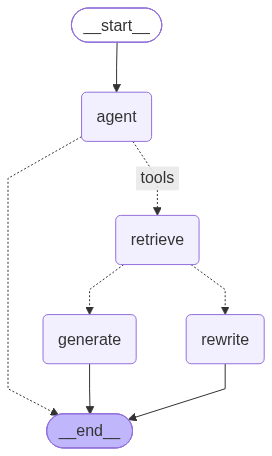

In [73]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [74]:
graph.invoke({"messages":"What is langchain"})

---CALL AGENT---


{'messages': [HumanMessage(content='What is langchain', additional_kwargs={}, response_metadata={}, id='99638540-9299-43a3-bfd1-8ad3c068a888'),
  AIMessage(content='**LangChain** is an open‑source framework designed to make it easier to build applications that use large language models (LLMs). It sits on top of popular LLM providers (OpenAI, Anthropic, Gemini, Cohere, etc.) and gives developers a high‑level, reusable set of abstractions for the common patterns that arise when building LLM‑powered software.\n\n### Core ideas\n\n| Concept | What it does | Typical use |\n|---------|--------------|-------------|\n| **Prompt templates** | Define a reusable prompt with placeholders that can be filled at runtime. | Generating consistent questions, summaries, or instructions. |\n| **LLM wrappers** | Wrap a model’s API call into a simple Python object. | Switching between models or providers with minimal code changes. |\n| **Chains** | Sequence of calls (e.g., prompt → LLM → post‑processing). |

In [75]:
inputs={
    "messages": [
        ("user", "What is MAchine LEarning"),
    ]
}
for output in graph.stream(inputs):
    print(output)

---CALL AGENT---
{'agent': {'messages': [AIMessage(content='**Machine Learning (ML)** is a subfield of artificial intelligence that focuses on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention.\n\n| Aspect | What it means |\n|--------|---------------|\n| **Learning from data** | Models are trained on examples (input–output pairs, or unlabeled data) and adjust internal parameters to improve performance. |\n| **Pattern recognition** | Algorithms detect regularities, clusters, or relationships that are not explicitly programmed. |\n| **Autonomous decision‑making** | Once trained, the model can predict outcomes, classify new data, or take actions without being told how to do it step by step. |\n\n### Core types of Machine Learning\n\n| Type | Typical problem | Example |\n|------|-----------------|---------|\n| **Supervised learning** | Predict a label or value for new inputs. | Image classification, spam detection, house‑price 